In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Keith Althea R. Camilet"
student_id = "20250614"

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

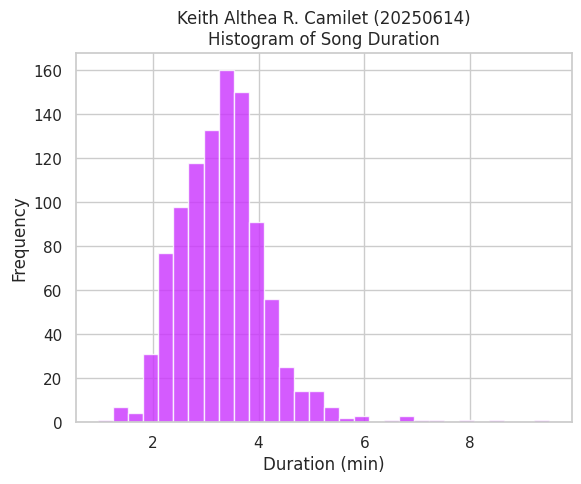

In [5]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.8)

plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel("Duration (min)")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_579/3404898594.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


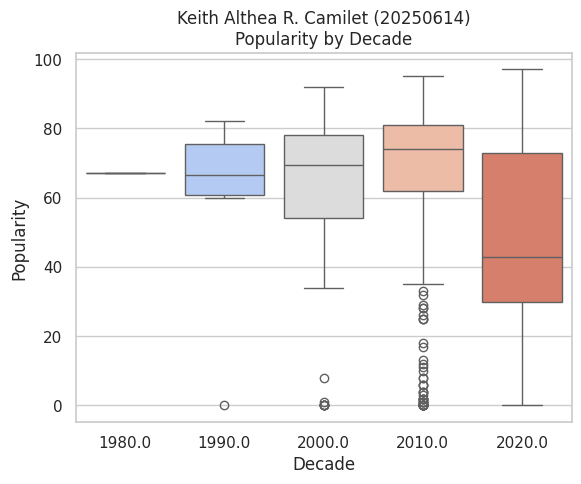

In [8]:
# Convert release_date → year → decade
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

df['decade'] = (df['release_year'] // 10) * 10

sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')

plt.title(f"{student_name} ({student_id})\nPopularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Popularity")

plt.show()

/tmp/ipykernel_579/794154360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


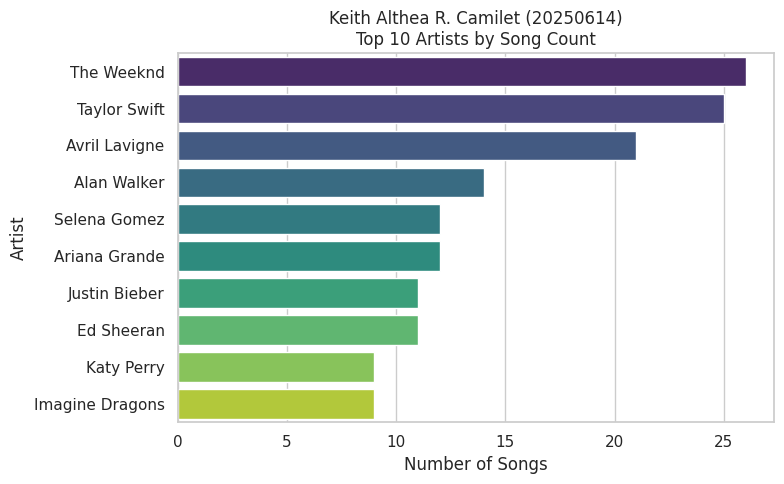

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='artist',
    data=df,
    order=df['artist'].value_counts().head(10).index,
    palette='viridis'
)

plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.tight_layout()
plt.show()

/tmp/ipykernel_579/213412671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_579/213412671.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


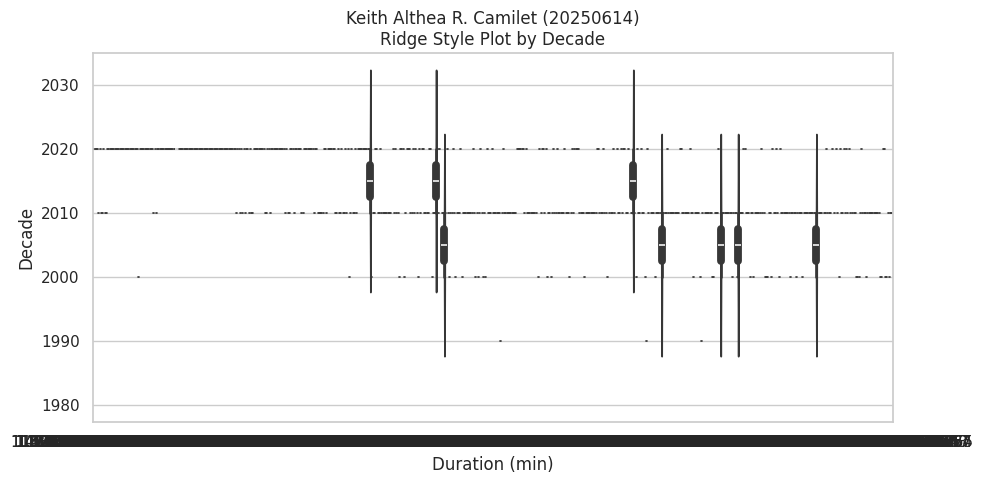

In [31]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x='duration_min',
    y='decade',
    palette='coolwarm',
    scale='width'
)

plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.xlabel("Duration (min)")
plt.ylabel("Decade")

plt.tight_layout()
plt.show()

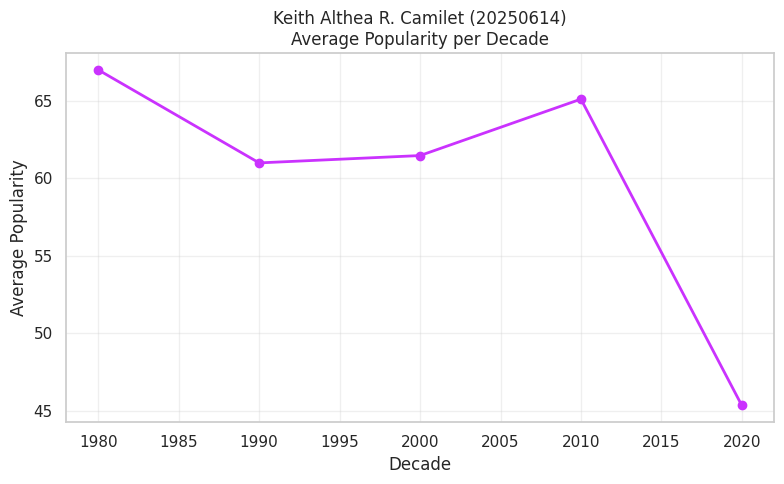

In [11]:
avg_pop = df.groupby('decade')['popularity'].mean()

plt.figure(figsize=(8,5))

avg_pop.plot(
    kind='line',
    color=color1,
    marker='o',
    linewidth=2
)

plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel("Decade")
plt.ylabel("Average Popularity")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

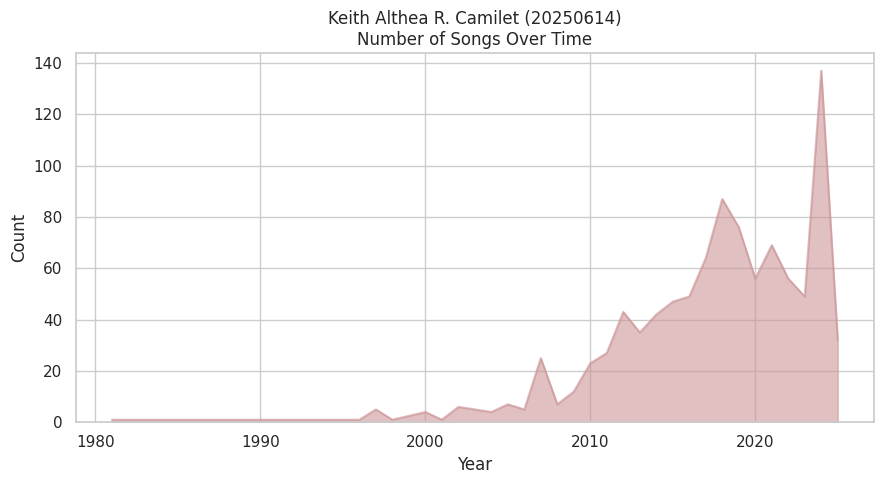

In [12]:
count_by_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(9,5))

count_by_year.plot(
    kind='area',
    color=color2,
    alpha=0.6
)

plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel("Year")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

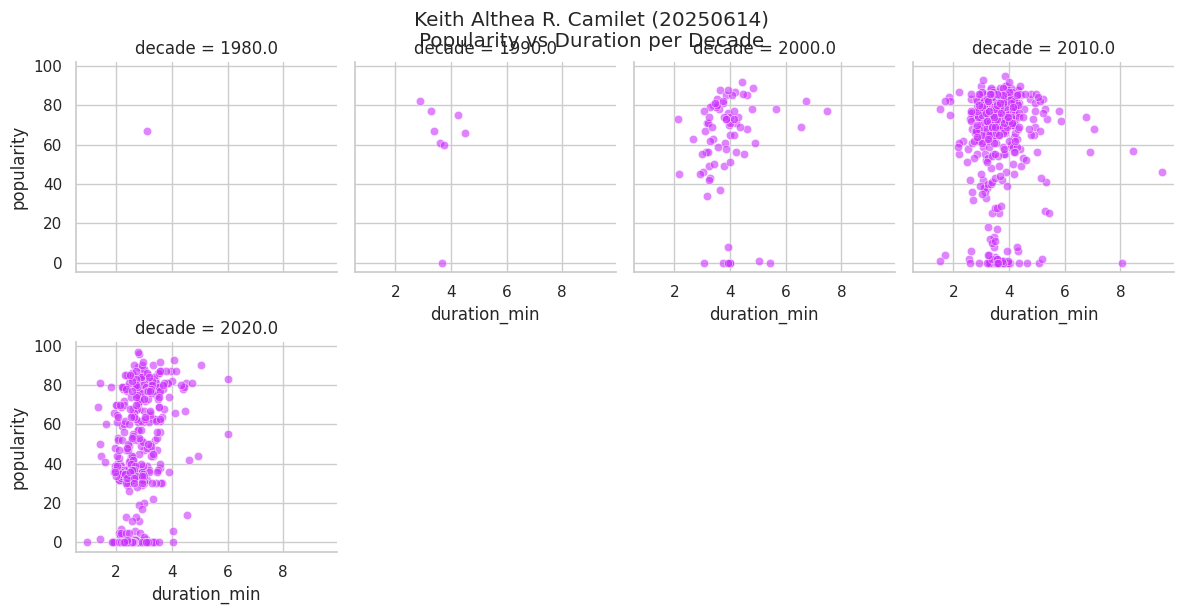

In [15]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(
    sns.scatterplot,
    x='duration_min',
    y='popularity',
    color=color1,
    alpha=0.6
)

g.fig.suptitle(
    f"{student_name} ({student_id})\nPopularity vs Duration per Decade",
    y=1.02
)

plt.show()

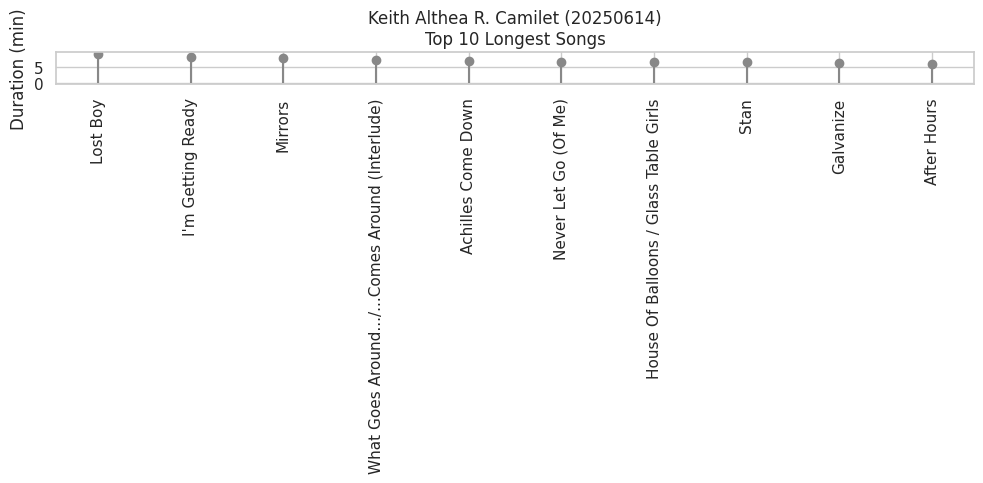

In [17]:
longest = df.nlargest(10, 'duration_min')

plt.figure(figsize=(10,5))

plt.stem(
    longest['track_name'],
    longest['duration_min'],
    linefmt='#888888',
    markerfmt='o',
    basefmt=" "
)

plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel("Duration (min)")

plt.tight_layout()
plt.show()

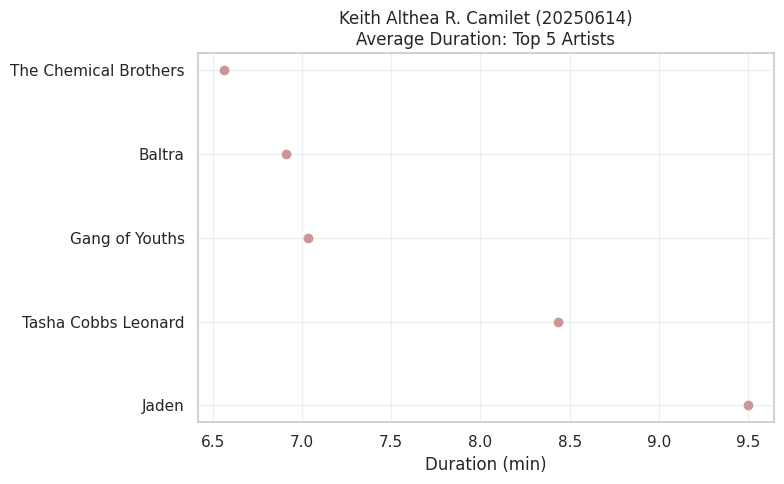

In [18]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)

plt.figure(figsize=(8,5))

plt.plot(
    avg_duration.values,
    avg_duration.index,
    'o',
    color=color2
)

plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel("Duration (min)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

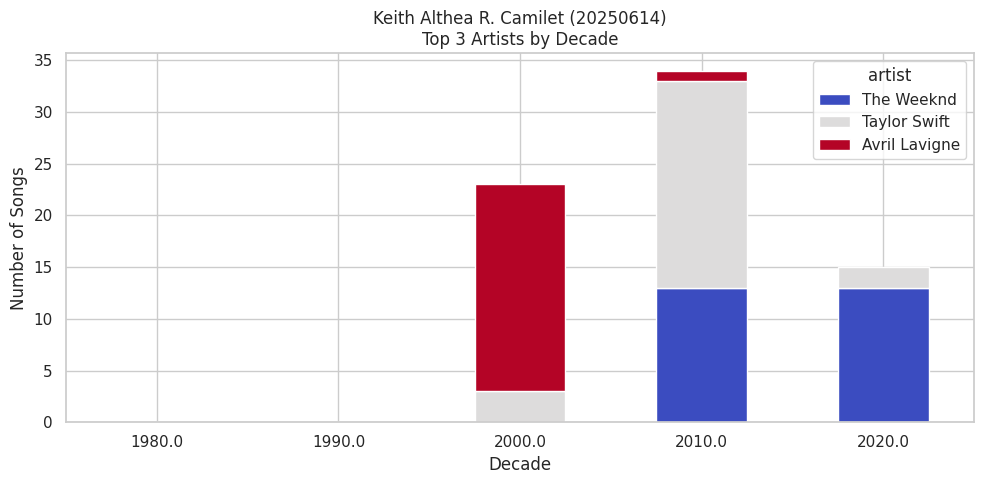

In [19]:
crosstab = pd.crosstab(df['decade'], df['artist'])

top3 = df['artist'].value_counts().head(3).index

crosstab[top3].plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm',
    figsize=(10,5)
)

plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel("Number of Songs")
plt.xlabel("Decade")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

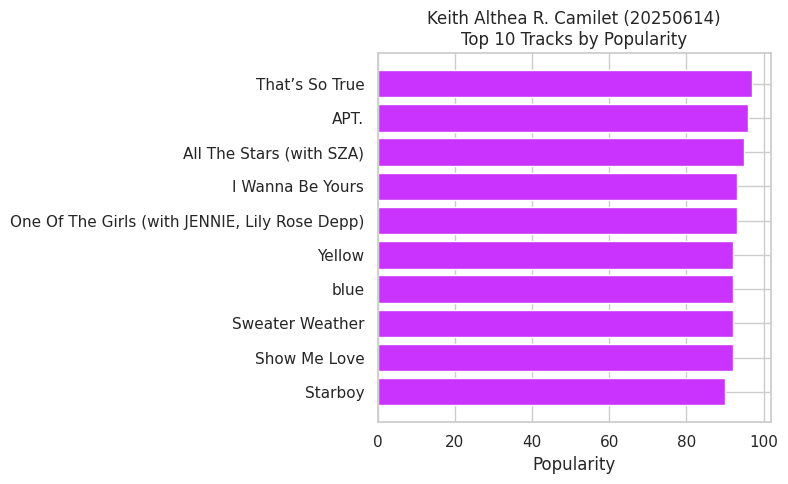

In [20]:
top_tracks = df.nlargest(10, 'popularity')

plt.figure(figsize=(8,5))

plt.barh(
    top_tracks['track_name'],
    top_tracks['popularity'],
    color=color1
)

plt.xlabel("Popularity")
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/tmp/ipykernel_579/1660155966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


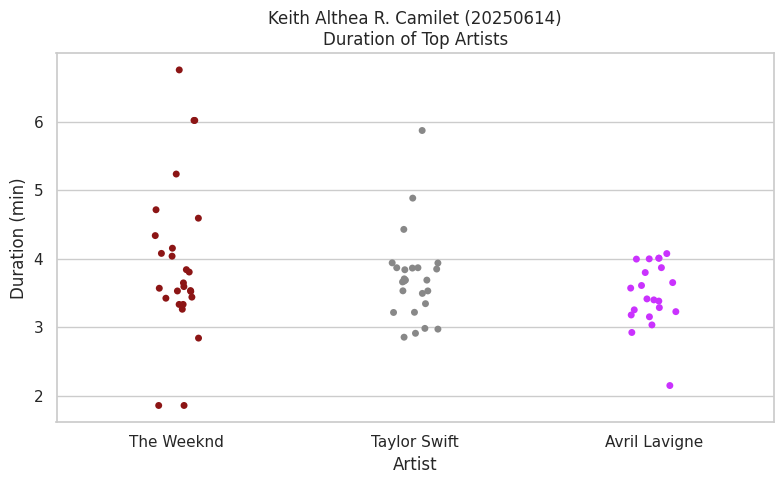

In [21]:
top_artists = df['artist'].value_counts().head(3).index

plt.figure(figsize=(8,5))

sns.stripplot(
    data=df[df['artist'].isin(top_artists)],
    x='artist',
    y='duration_min',
    palette=['#8C1515', '#888888', color1]
)

plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.xlabel("Artist")
plt.ylabel("Duration (min)")

plt.tight_layout()
plt.show()

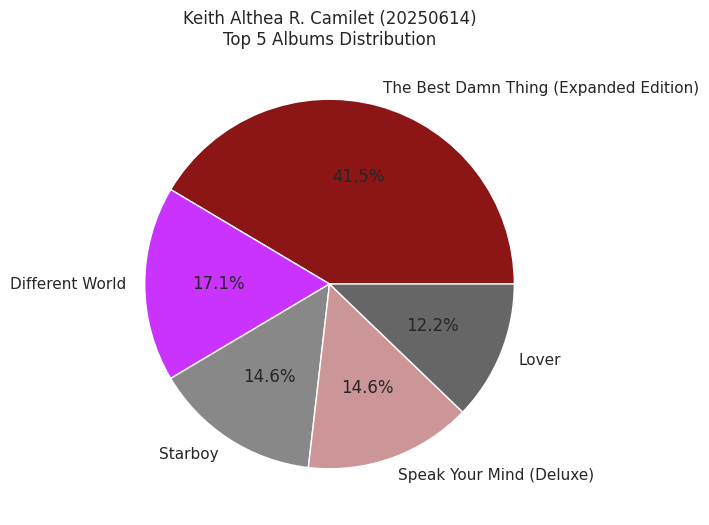

In [22]:
top_albums = df['album'].value_counts().head(5)

colors = ['#8C1515', color1, '#888888', color2, '#666666']

plt.figure(figsize=(6,6))

plt.pie(
    top_albums,
    labels=top_albums.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")

plt.show()

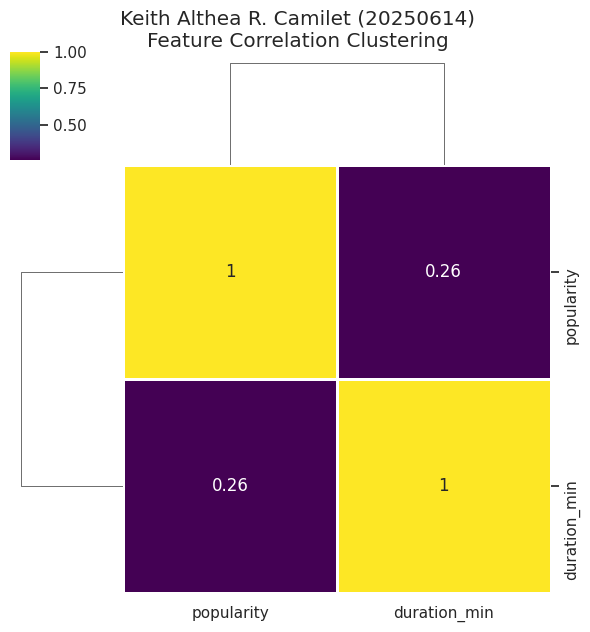

In [23]:
numerical_cols = ['popularity', 'duration_min']

df_numeric = df[numerical_cols].dropna()

sns.clustermap(
    df_numeric.corr(),
    annot=True,
    cmap='viridis',
    linewidths=0.75,
    figsize=(6,6)
)

plt.suptitle(
    f"{student_name} ({student_id})\nFeature Correlation Clustering",
    y=1.05
)

plt.show()

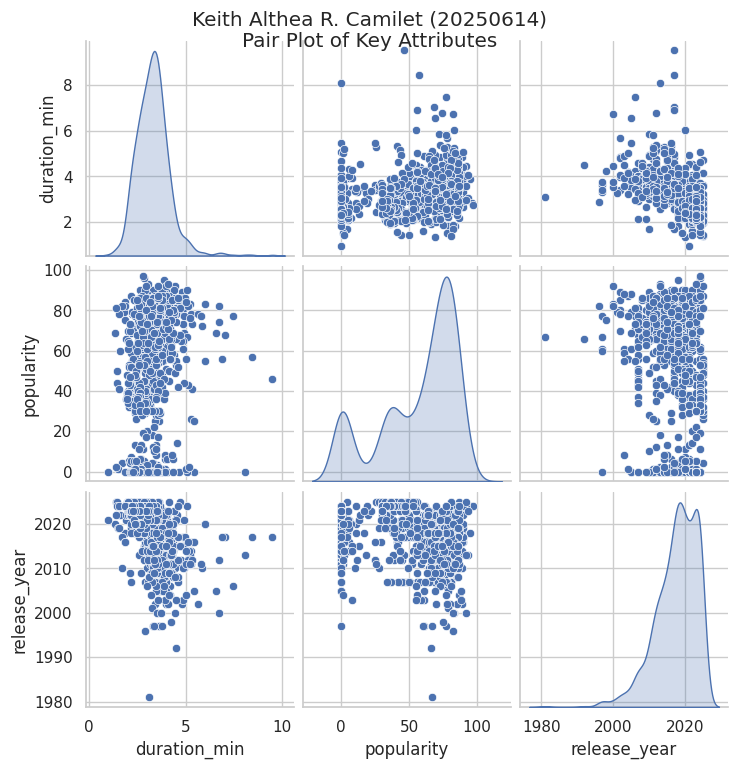

In [24]:
sns.pairplot(
    df[['duration_min', 'popularity', 'release_year']].dropna(),
    diag_kind='kde'
)

plt.suptitle(
    f"{student_name} ({student_id})\nPair Plot of Key Attributes",
    y=1.02
)

plt.show()

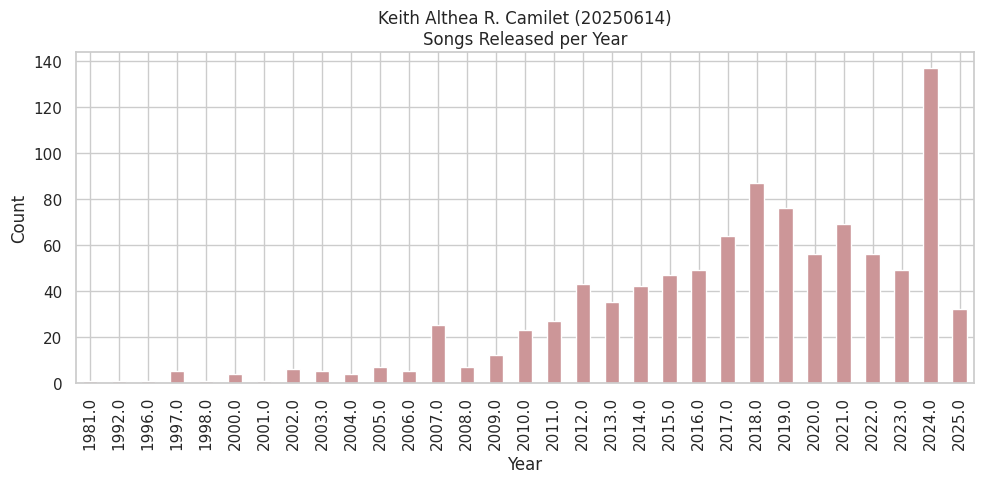

In [25]:
plt.figure(figsize=(10,5))

df['release_year'].value_counts().sort_index().plot(
    kind='bar',
    color=color2
)

plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

/tmp/ipykernel_579/2057162703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


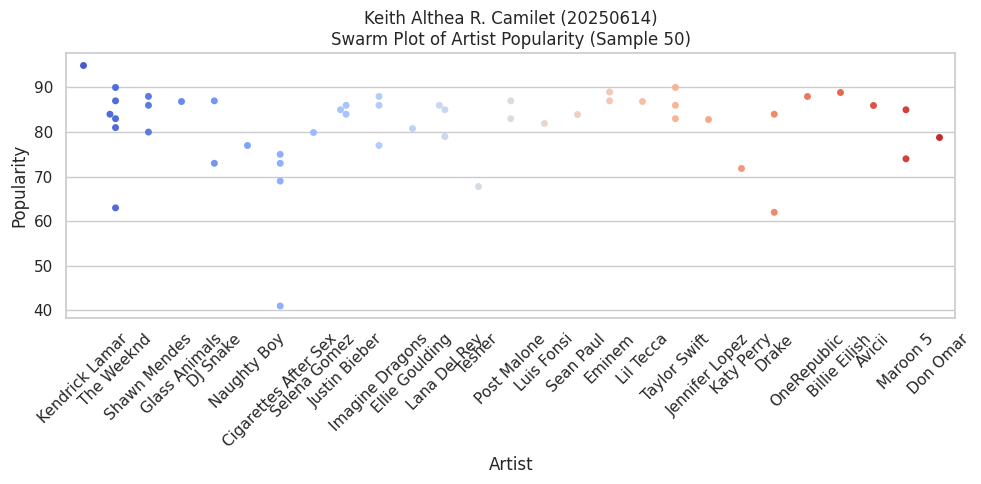

In [26]:
plt.figure(figsize=(10,5))

sns.swarmplot(
    data=df.head(50),
    x='artist',
    y='popularity',
    palette='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xlabel("Artist")
plt.ylabel("Popularity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

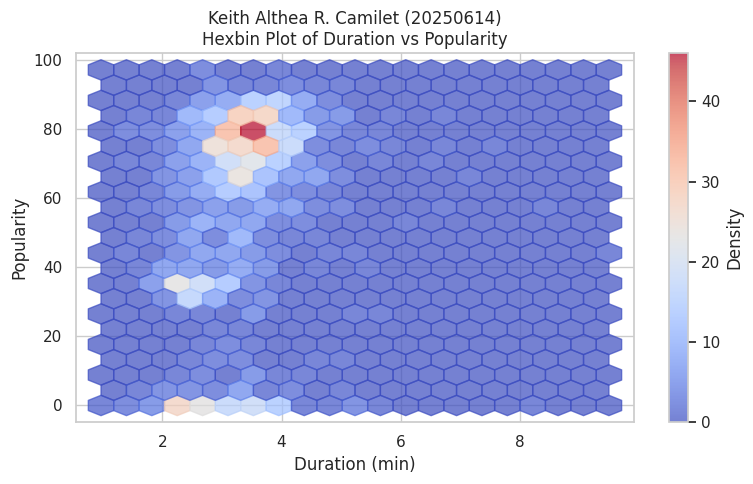

In [27]:
plt.figure(figsize=(8,5))

plt.hexbin(
    df['duration_min'],
    df['popularity'],
    gridsize=20,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("Duration (min)")
plt.ylabel("Popularity")

plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")

plt.colorbar(label="Density")
plt.tight_layout()
plt.show()

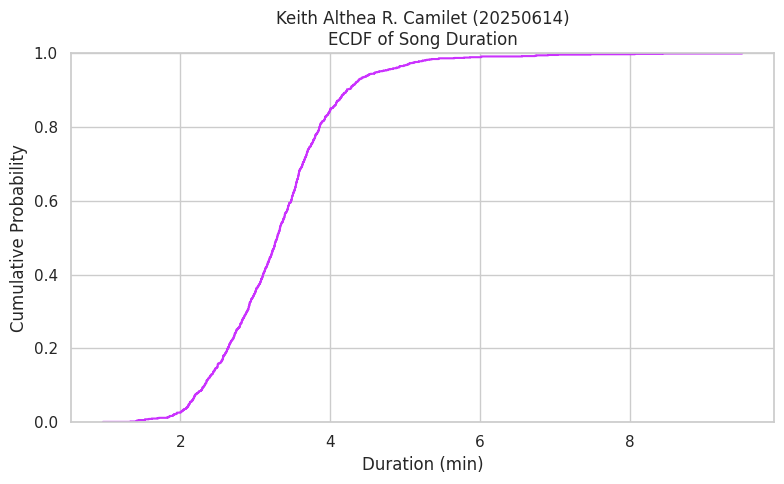

In [28]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df,
    x='duration_min',
    color=color1
)

plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel("Duration (min)")
plt.ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

In [29]:
top3 = df['artist'].value_counts().head(3).index

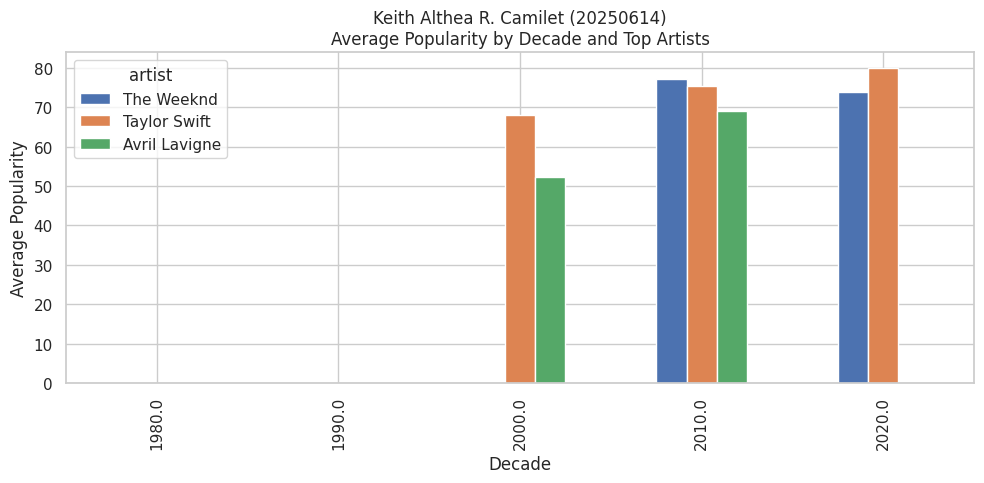

In [30]:
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

# Ensure top3 exists in columns
avg_artist_decade[top3].plot(kind='bar', figsize=(10,5))

plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.xlabel("Decade")
plt.ylabel("Average Popularity")

plt.tight_layout()
plt.show()